In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from fetch_separate_datasets import fetch_data
from model_pipelines import ModelConstructor

In [2]:
plt.rcParams['figure.dpi'] = 300

### Model A: Early Prediction

In [3]:
scores = []
m = ModelConstructor('A')
x_train, x_test, y_train, y_test_A = m.fetch_splits(label_encode=False)

## One hot encode Y
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test_A = le.fit_transform(y_test_A)

ohe = OneHotEncoder(sparse_output=False)
y_train = ohe.fit_transform(y_train.reshape(-1, 1))
y_test_A = ohe.fit_transform(y_test_A.reshape(-1, 1))

for i in range(100):
    model = m.fetch_pipelines('plsda', i+1)
    model.fit(x_train, y_train)
    scores.append(model.score(x_test, y_test_A))

scores_A = np.array(scores)
n_comp_A = np.where(scores_A == scores_A.max())[0][0]

Text(4, 0.5, 'Best F1 at 3 components')

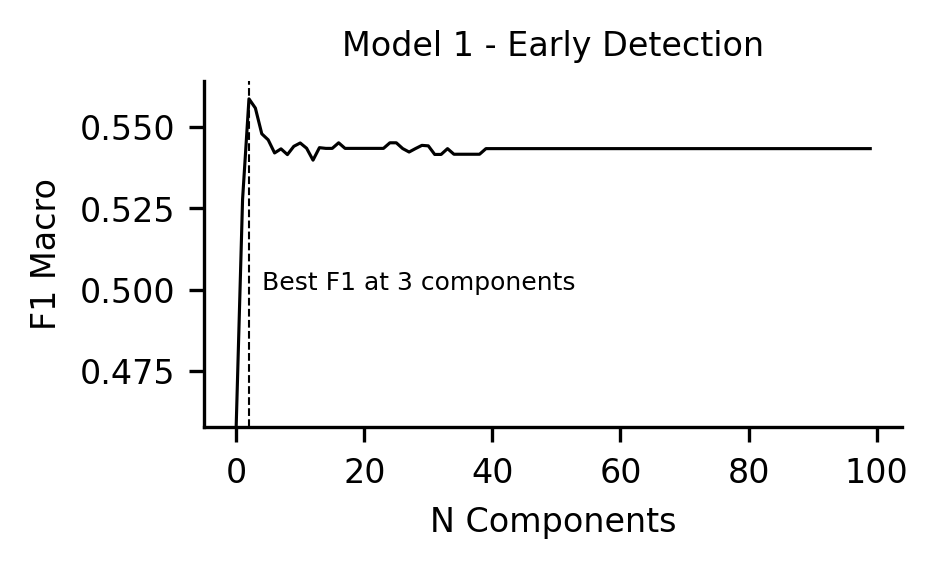

In [4]:
fig, ax = plt.subplots(figsize = (3,1.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = 8)

ax.plot(scores_A, linewidth = 0.75, color = 'black')
ax.plot(
    [n_comp_A]*100, 
    np.linspace(scores_A.min(), scores_A.max() + scores_A.max()*0.01, 100),
    '--', color = 'black', linewidth = 0.5
)
ax.set_ylim(scores_A.min(), scores_A.max() + scores_A.max()*0.01)
ax.set_xlabel("N Components", fontsize = 8)
ax.set_ylabel("F1 Macro", fontsize = 8)
ax.set_title("Model 1 - Early Detection", fontsize = 8)
ax.text(n_comp_A+2, 0.5, f'Best F1 at {n_comp_A+1} components', fontsize = 6)

In [5]:
model_A = m.fetch_pipelines('plsda', n_comp_A+1)
model_A.fit(x_train, y_train)
Y_pred_A = model_A.predict(x_test)
cmA = confusion_matrix(np.argmax(y_test_A, axis = 1), Y_pred_A)

### Model B: Enrolled detection

In [6]:
scores = []
m = ModelConstructor('B')
x_train, x_test, y_train, y_test_B = m.fetch_splits(label_encode=False)

## One hot encode Y
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test_B = le.fit_transform(y_test_B)

ohe = OneHotEncoder(sparse_output=False)
y_train = ohe.fit_transform(y_train.reshape(-1, 1))
y_test_B = ohe.fit_transform(y_test_B.reshape(-1, 1))

for i in range(12):
    model = m.fetch_pipelines('plsda', i+1)
    model.fit(x_train, y_train)
    scores.append(model.score(x_test, y_test_B))

scores_B = np.array(scores)
n_comp_B = np.where(scores_B == scores_B.max())[0][0]

Text(6.25, 0.6, 'Best F1 at 7 components')

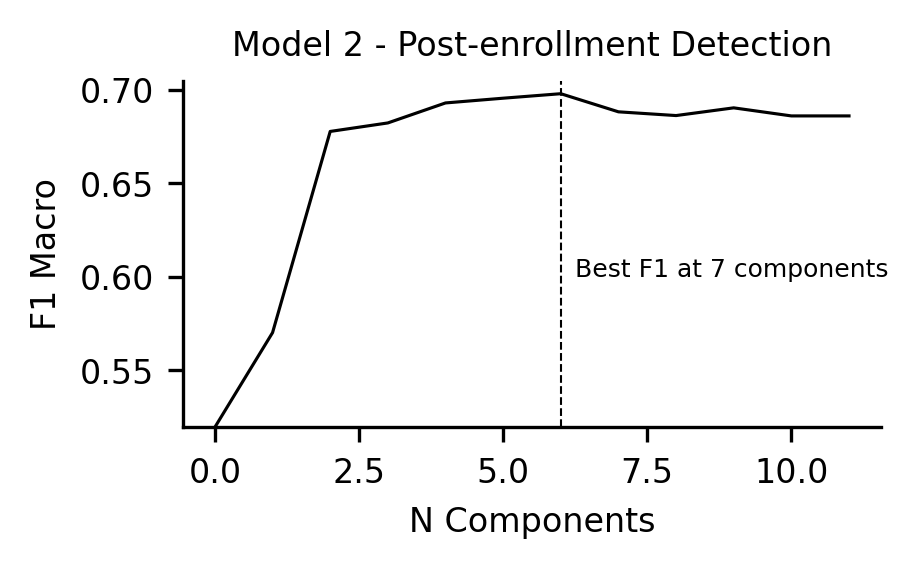

In [7]:
fig, ax = plt.subplots(figsize = (3,1.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = 8)

ax.plot(scores_B, linewidth = 0.75, color = 'black')
ax.plot(
    [n_comp_B]*100, 
    np.linspace(scores_B.min(), scores_B.max() + scores_B.max()*0.01, 100),
    '--', color = 'black', linewidth = 0.5
)
ax.set_ylim(scores_B.min(), scores_B.max() + scores_B.max()*0.01)
ax.set_xlabel("N Components", fontsize = 8)
ax.set_ylabel("F1 Macro", fontsize = 8)
ax.set_title("Model 2 - Post-enrollment Detection", fontsize = 8)
ax.text(n_comp_B+0.25, 0.6, f'Best F1 at {n_comp_B+1} components', fontsize = 6)

In [8]:
model_B = m.fetch_pipelines('plsda', n_comp_B+1)
model_B.fit(x_train, y_train)
Y_pred_B = model_B.predict(x_test)
cmB = confusion_matrix(np.argmax(y_test_B, axis = 1), Y_pred_B)

### Model C: Combined pre-and post enrollment detection

In [9]:
scores = []
m = ModelConstructor('C')
x_train, x_test, y_train, y_test_C = m.fetch_splits(label_encode=False)

## One hot encode Y
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test_C = le.fit_transform(y_test_C)

ohe = OneHotEncoder(sparse_output=False)
y_train = ohe.fit_transform(y_train.reshape(-1, 1))
y_test_C = ohe.fit_transform(y_test_C.reshape(-1, 1))

for i in range(100):
    model = m.fetch_pipelines('plsda', i+1)
    model.fit(x_train, y_train)
    scores.append(model.score(x_test, y_test_C))

scores_C = np.array(scores)
n_comp_C = np.where(scores_C == scores_C.max())[0][0]

Text(12.25, 0.6, 'Best F1 at 13 components')

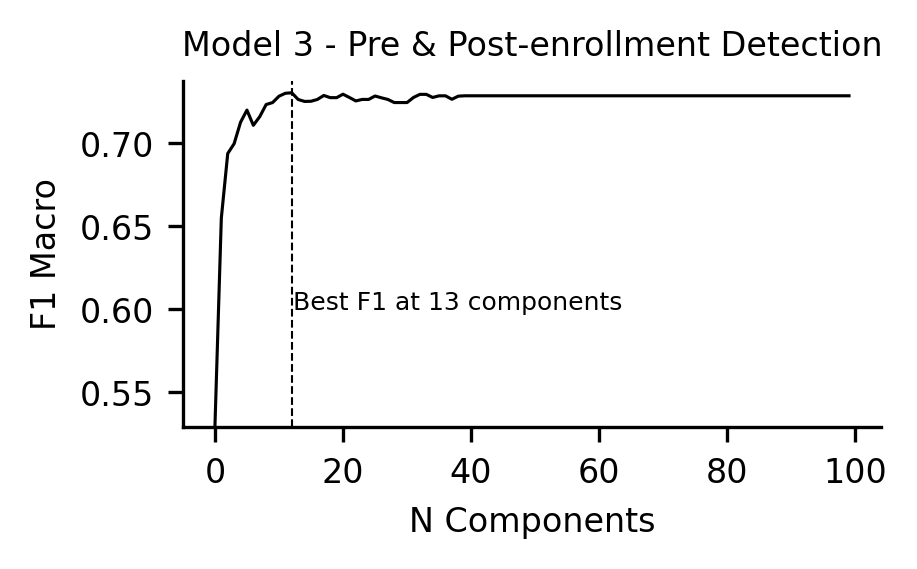

In [10]:
fig, ax = plt.subplots(figsize = (3,1.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = 8)

ax.plot(scores_C, linewidth = 0.75, color = 'black')
ax.plot(
    [n_comp_C]*100, 
    np.linspace(scores_C.min(), scores_C.max() + scores_C.max()*0.01, 100),
    '--', color = 'black', linewidth = 0.5
)
ax.set_ylim(scores_C.min(), scores_C.max() + scores_C.max()*0.01)
ax.set_xlabel("N Components", fontsize = 8)
ax.set_ylabel("F1 Macro", fontsize = 8)
ax.set_title("Model 3 - Pre & Post-enrollment Detection", fontsize = 8)
ax.text(n_comp_C+0.25, 0.6, f'Best F1 at {n_comp_C+1} components', fontsize = 6)

In [11]:
model_C = m.fetch_pipelines('plsda', n_comp_C+1)
model_C.fit(x_train, y_train)
Y_pred_C = model_B.predict(x_test)
cmC = confusion_matrix(np.argmax(y_test_C, axis = 1), Y_pred_C)

### Performance summary

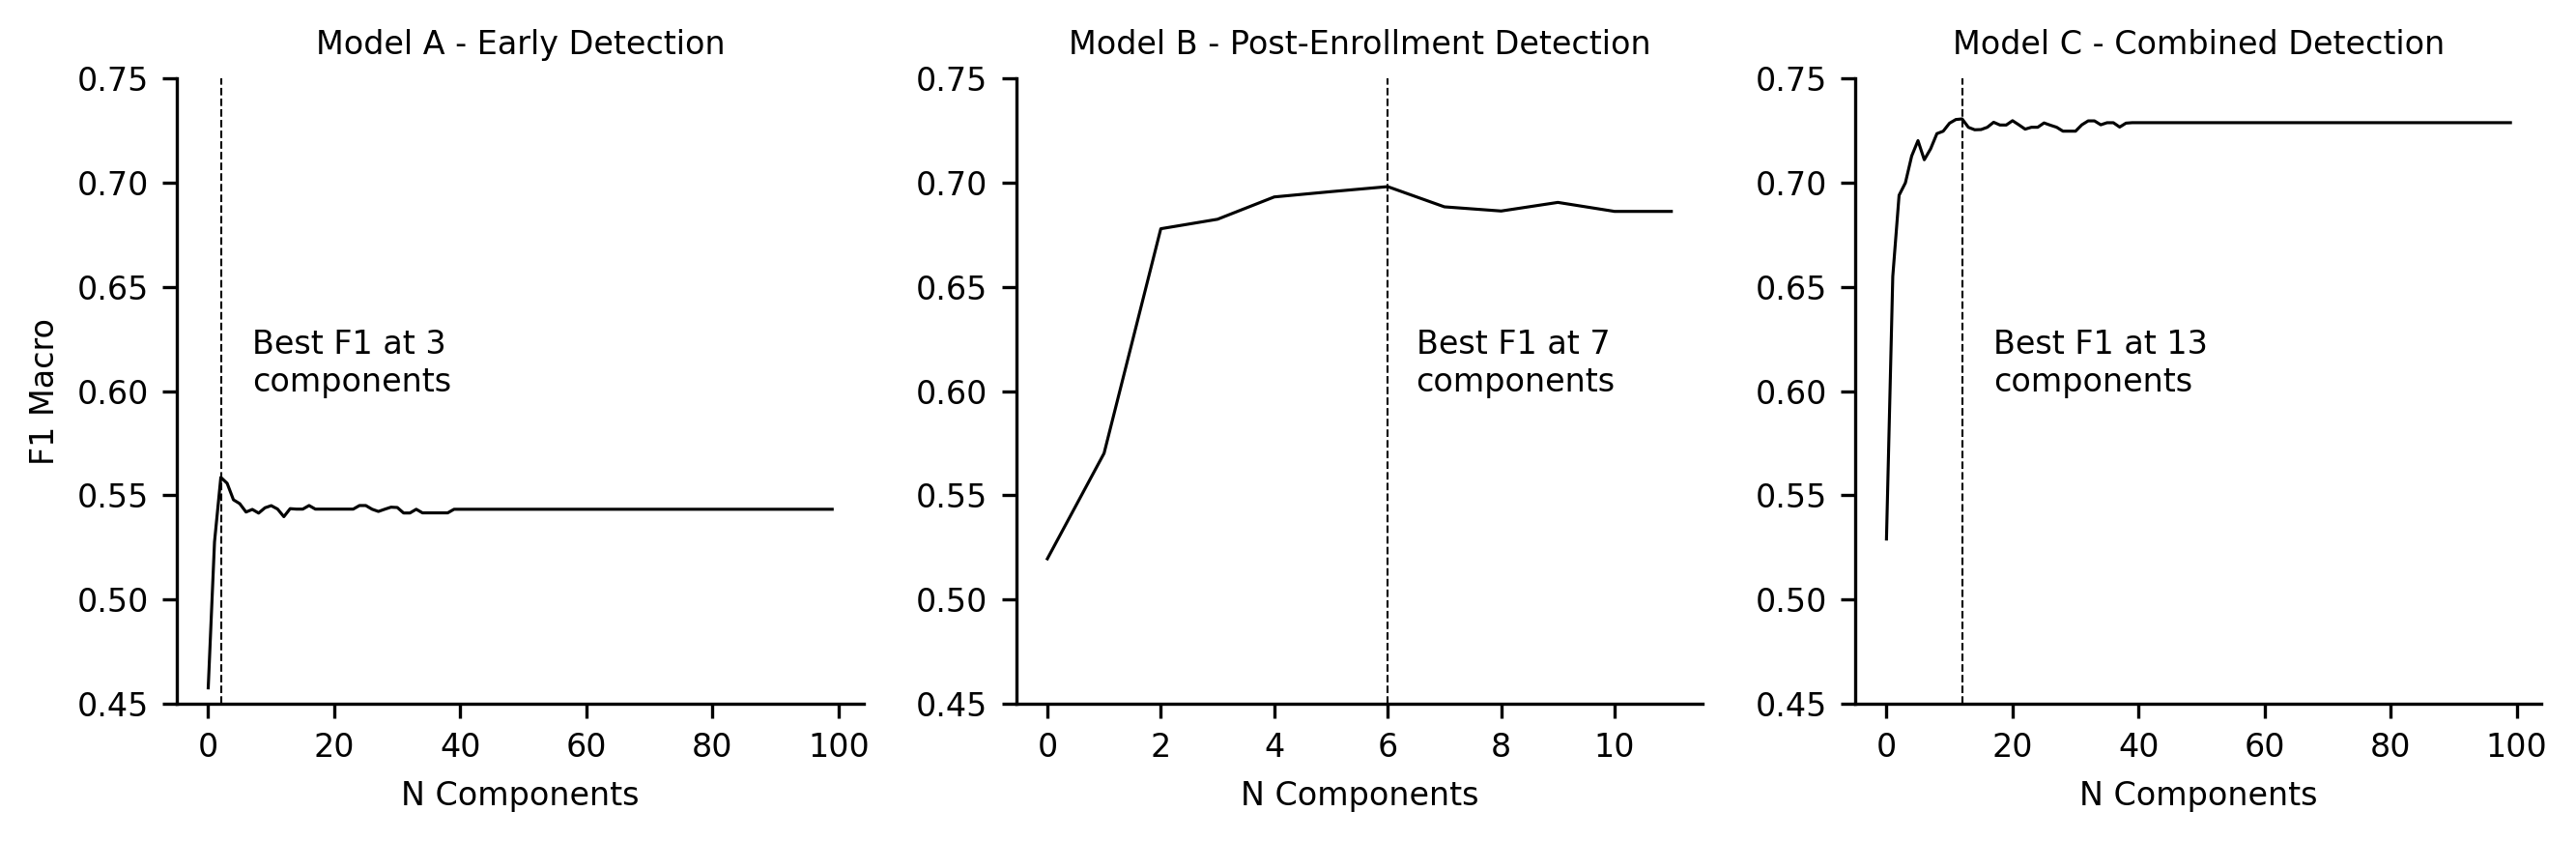

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(9, 3))

model_data = [
    {'scores': scores_A, 'n_comp': n_comp_A, 'title': 'Model A - Early Detection'},
    {'scores': scores_B, 'n_comp': n_comp_B, 'title': 'Model B - Post-Enrollment Detection'},
    {'scores': scores_C, 'n_comp': n_comp_C, 'title': 'Model C - Combined Detection'},
]

annot_offsets = [5,0.5,5]
i = 0
for i, d in enumerate(model_data):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize=8)

    ax[i].plot(d['scores'], linewidth=0.75, color='black')
    ax[i].plot(
        [d['n_comp']] * 100,
        np.linspace(0.45, 0.75, 100),
        '--', color='black', linewidth=0.5
    )
    ax[i].set_ylim(d['scores'].min(), d['scores'].max() + d['scores'].max() * 0.01)
    ax[i].set_xlabel("N Components", fontsize=8)
    ax[i].set_title(d['title'], fontsize=8)
    ax[i].text(d['n_comp'] + annot_offsets[i], 0.6, f'Best F1 at {d["n_comp"] + 1}\ncomponents', fontsize=8)
    ax[i].set_ylim(0.45, 0.75)
    i+=1

ax[0].set_ylabel("F1 Macro", fontsize=8)
plt.tight_layout()

In [13]:
from ucimlrepo import fetch_ucirepo 
Y = fetch_ucirepo(id=697).data.targets 

Text(0.5, 1.0, 'Model C - total F1 = 0.73')

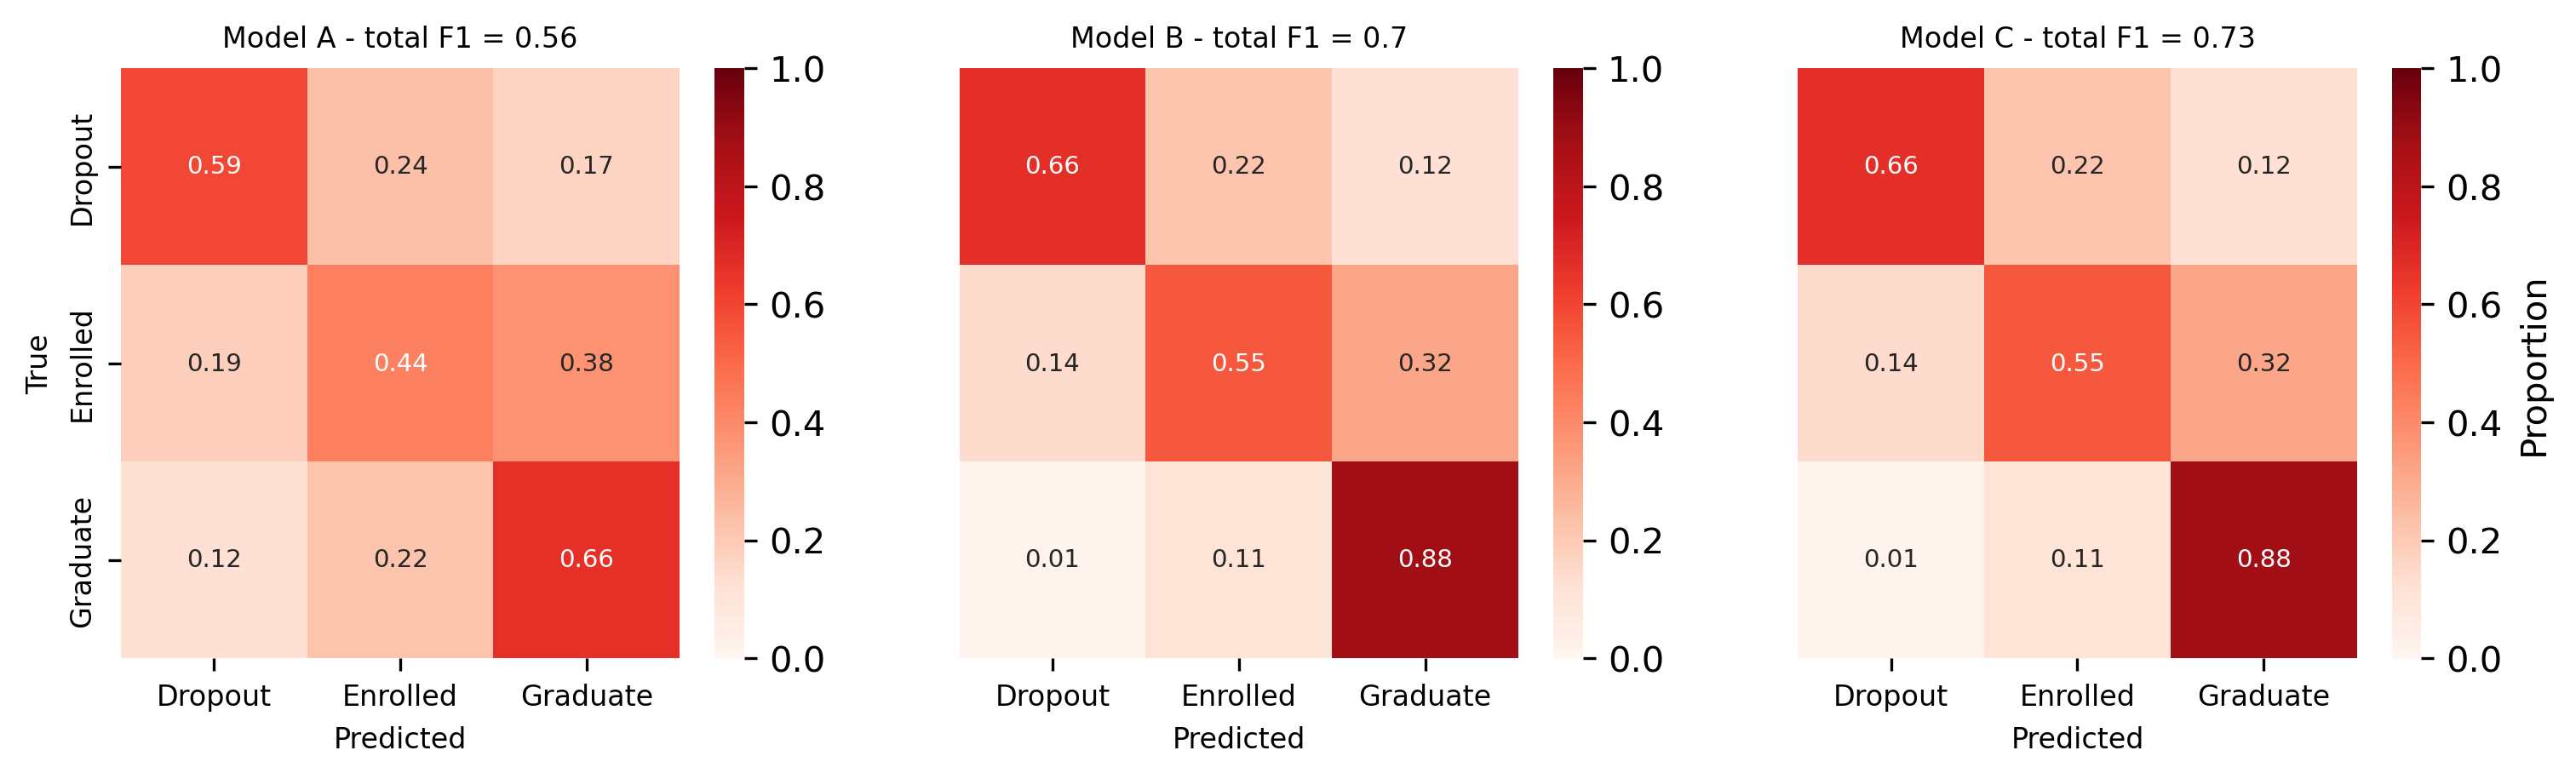

In [14]:
fig, ax = plt.subplots(1,3, figsize = (12,3))

sns.heatmap(cmA/cmA.sum(axis=1, keepdims=True), ax = ax[0], cmap = 'Reds', vmin = 0, vmax = 1, annot = True, fmt = '.2f', annot_kws = {'size': 7})
sns.heatmap(cmB/cmB.sum(axis=1, keepdims=True), ax = ax[1], cmap = 'Reds', vmin = 0, vmax = 1, annot = True, fmt = '.2f', annot_kws = {'size': 7})
sns.heatmap(cmC/cmC.sum(axis=1, keepdims=True), ax = ax[2], cmap = 'Reds', vmin = 0, vmax = 1, annot = True, fmt = '.2f', annot_kws = {'size': 7}, cbar_kws = {'label': 'Proportion'})

for i in range(3):
    ax[i].tick_params(labelsize = 8)
    ax[i].set_xlabel("Predicted", fontsize = 8)
    if i>0:
        ax[i].set_yticks([])
    ax[i].set_xticklabels(np.unique(Y.values))
    
ax[0].set_ylabel("True", fontsize = 8)
ax[0].set_yticklabels(np.unique(Y.values))

ax[0].set_title(f"Model A - total F1 = {scores_A.max().round(2)}", fontsize = 8)
ax[1].set_title(f"Model B - total F1 = {scores_B.max().round(2)}", fontsize = 8)
ax[2].set_title(f"Model C - total F1 = {scores_C.max().round(2)}", fontsize = 8)

In [15]:
## Model A
print(classification_report(Y_pred_A, np.argmax(y_test_A, axis = 1), target_names = np.unique(Y.values)))

              precision    recall  f1-score   support

     Dropout       0.59      0.71      0.64       264
    Enrolled       0.44      0.28      0.34       233
    Graduate       0.66      0.71      0.69       388

    accuracy                           0.60       885
   macro avg       0.56      0.57      0.56       885
weighted avg       0.58      0.60      0.58       885



In [16]:
## Model B
print(classification_report(Y_pred_B, np.argmax(y_test_B, axis = 1), target_names = np.unique(Y.values)))

              precision    recall  f1-score   support

     Dropout       0.66      0.88      0.76       209
    Enrolled       0.55      0.43      0.48       185
    Graduate       0.88      0.83      0.85       455

    accuracy                           0.75       849
   macro avg       0.70      0.71      0.70       849
weighted avg       0.76      0.75      0.75       849



In [17]:
## Model C
print(classification_report(Y_pred_C, np.argmax(y_test_C, axis = 1), target_names = np.unique(Y.values)))

              precision    recall  f1-score   support

     Dropout       0.66      0.88      0.76       209
    Enrolled       0.55      0.43      0.48       185
    Graduate       0.88      0.83      0.85       455

    accuracy                           0.75       849
   macro avg       0.70      0.71      0.70       849
weighted avg       0.76      0.75      0.75       849

